# TP Apprentissage Non Supervisé — Mall Customers Dataset

**Version corrigée pour correspondre à l'article scientifique.**

**Objectif :** Implémenter et comparer plusieurs algorithmes de clustering non supervisé sur le même dataset.

| # | Étape |
|---|---|
| 1 | Analyse Exploratoire (EDA) |
| 2 | Prétraitement (encodage, outliers, scaling) |
| 3 | Clustering : K-Means, DBSCAN, Agglomeratif, GMM, HDBSCAN, Spectral |
| 4 | Réduction de dimension : PCA, t-SNE, UMAP |
| 5 | Analyses avancées : stabilité, impact du scaling, ARI/NMI, Isolation Forest |
| 6 | Évaluation comparative complète |
| 7 | Visualisations finales |
| 8 | Interprétation métier des clusters |
| 9 | Résumé final & réponses aux questions |

> Note : Mean Shift est gardé comme section optionnelle du TP, mais il n'est pas inclus dans la comparaison finale de l'article, qui compare 6 algorithmes : K-Means, DBSCAN, Agglomerative, GMM, HDBSCAN et Spectral Clustering.

##  Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Prétraitement ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from scipy.stats import zscore

# ── Modèles de clustering ──────────────────────────────────────
from sklearn.cluster import (
    KMeans, DBSCAN, AgglomerativeClustering, MeanShift, SpectralClustering,
    estimate_bandwidth
)
from sklearn.mixture import GaussianMixture

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ModuleNotFoundError:
    hdbscan = None
    HDBSCAN_AVAILABLE = False
    print(' hdbscan n\'est pas installé ; la section HDBSCAN sera ignorée.')

# ── Détection d'outliers ───────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Évaluation clustering ──────────────────────────────────────
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# ── Réduction de dimension ─────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    import umap
    UMAP_AVAILABLE = True
except ModuleNotFoundError:
    umap = None
    UMAP_AVAILABLE = False
    print(' umap n\'est pas installé ; la section UMAP sera ignorée.')

# ── Hiérarchique ───────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage


plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Tous les imports réussis')
print('Bibliothèques chargées : sklearn, scipy, seaborn')
if HDBSCAN_AVAILABLE:
    print('Optionnel : hdbscan disponible')
else:
    print('hdbscan non installé — la section HDBSCAN sera ignorée.')
if UMAP_AVAILABLE:
    print('Optionnel : umap-learn disponible')
else:
    print(' umap-learn non installé — la section UMAP sera ignorée.')


Tous les imports réussis
Bibliothèques chargées : sklearn, scipy, seaborn
Optionnel : hdbscan disponible
Optionnel : umap-learn disponible


---
## 1. Analyse Exploratoire des Données (EDA)

> **Pourquoi ?** Avant tout modèle, il faut comprendre la structure du dataset :
> distributions, valeurs manquantes, relations entre variables et outliers potentiels.


### 1.1 Chargement et informations générales

In [2]:
#  Google Colab : uploadez d'abord le fichier puis décommentez :
# from google.colab import files; files.upload()
df_raw = pd.read_csv('Mall_Customers.csv')
df = df_raw.drop(columns=['CustomerID'])  # identifiant sans valeur prédictive

print(f'Dimensions  : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Colonnes    : {list(df.columns)}')
print()
df.info()


Dimensions  : 200 lignes × 4 colonnes
Colonnes    : ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [47]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

Missing values per column:
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Gender_encoded            0
dtype: int64

Total missing values in the dataset:
0


### Missing Values Check

The dataset was checked for missing values using `isnull().sum()`.  
No missing values were detected in any column, therefore no deletion or imputation was required.

### 1.2 Aperçu des données

In [3]:
df.head(10)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
5,Female,22,17,76
6,Female,35,18,6
7,Female,23,18,94
8,Male,64,19,3
9,Female,30,19,72


### 1.3 Valeurs manquantes

In [4]:
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing)
print(f'\nTotal : {missing.sum()} valeur(s) manquante(s)')


Valeurs manquantes par colonne :
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total : 0 valeur(s) manquante(s)


### 1.4 Statistiques descriptives

In [5]:
df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


### 1.5 Répartition du Genre

In [6]:
print('Répartition Gender :')
print(df['Gender'].value_counts())
print(f'\nProportion : {df["Gender"].value_counts(normalize=True).round(3).to_dict()}')


Répartition Gender :
Gender
Female    112
Male       88
Name: count, dtype: int64

Proportion : {'Female': 0.56, 'Male': 0.44}


### 1.6 Histogrammes et Boxplots

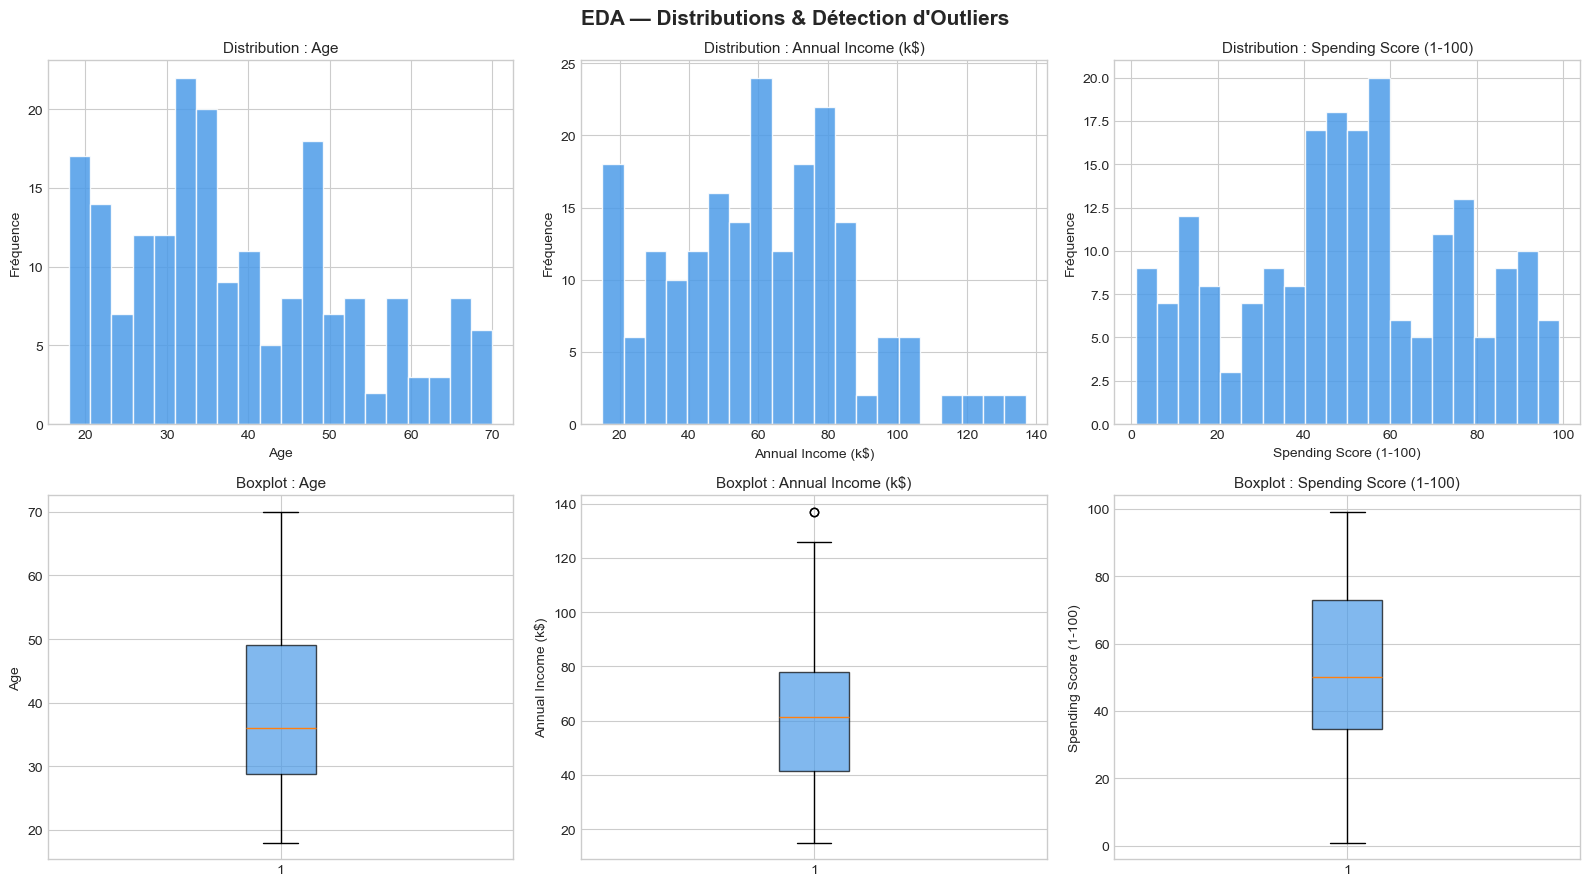

In [7]:
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Distributions & Détection d\'Outliers', fontsize=15, fontweight='bold')

for i, col in enumerate(numerical_cols):
    axes[0, i].hist(df[col], bins=20, color='#4C9BE8', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Distribution : {col}', fontsize=11)
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel('Fréquence')

for i, col in enumerate(numerical_cols):
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='#4C9BE8', alpha=0.7))
    axes[1, i].set_title(f'Boxplot : {col}', fontsize=11)
    axes[1, i].set_ylabel(col)

plt.tight_layout(); plt.show()


### 1.7 Matrice de corrélation

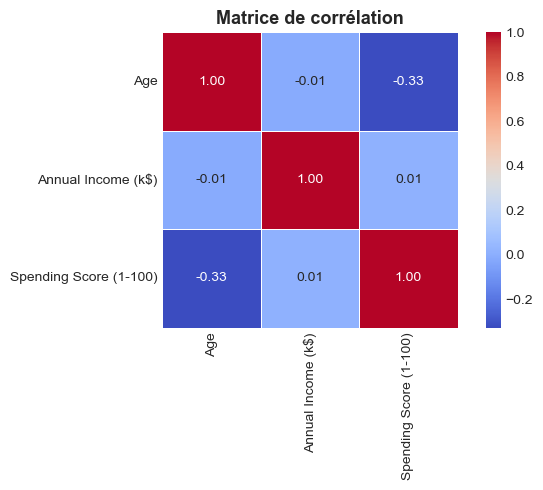

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2. Prétraitement

> **Pipeline :** Encodage catégoriel → Isolation Forest (outliers avancé) → Z-score → Normalisation


### 2.1 Encodage Label de Gender

In [9]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
print(f'Mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Labels réels (Gender encodé) — utilisés plus tard pour ARI/NMI
gender_labels = df['Gender_encoded'].values

df_num = df.drop(columns=['Gender'])
features = df_num.columns.tolist()
print(f'Colonnes numériques : {features}')
df_num.head()


Mapping : {'Female': np.int64(0), 'Male': np.int64(1)}
Colonnes numériques : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']


,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


### 2.2 Détection d'outliers — Isolation Forest (méthode avancée)

> **Isolation Forest** isole les anomalies en construisant des arbres aléatoires.
> Les points qui nécessitent peu de coupures pour être isolés sont des outliers.
> C'est une méthode plus robuste que le Z-score pour des distributions complexes.


In [10]:
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_pred   = iso_forest.fit_predict(df_num[features])
# fit_predict renvoie 1 (inlier) ou -1 (outlier)
outliers_iso = (iso_pred == -1)

print(f'Outliers détectés par Isolation Forest : {outliers_iso.sum()} ')
print(f'  ({outliers_iso.sum()/len(df_num)*100:.1f}% du dataset)')
print('\nProfil des outliers détectés :')
print(df_num[outliers_iso].describe().round(2))


Outliers détectés par Isolation Forest : 10 
  (5.0% du dataset)

Profil des outliers détectés :
         Age  Annual Income (k$)  Spending Score (1-100)  Gender_encoded
count  10.00               10.00                   10.00           10.00
mean   37.90               83.90                   41.70            0.70
std    16.50               54.27                   38.20            0.48
min    18.00               16.00                    3.00            0.00
25%    30.50               22.50                    9.50            0.25
50%    32.50              113.00                   23.00            1.00
75%    43.25              126.00                   80.75            1.00
max    67.00              137.00                   92.00            1.00


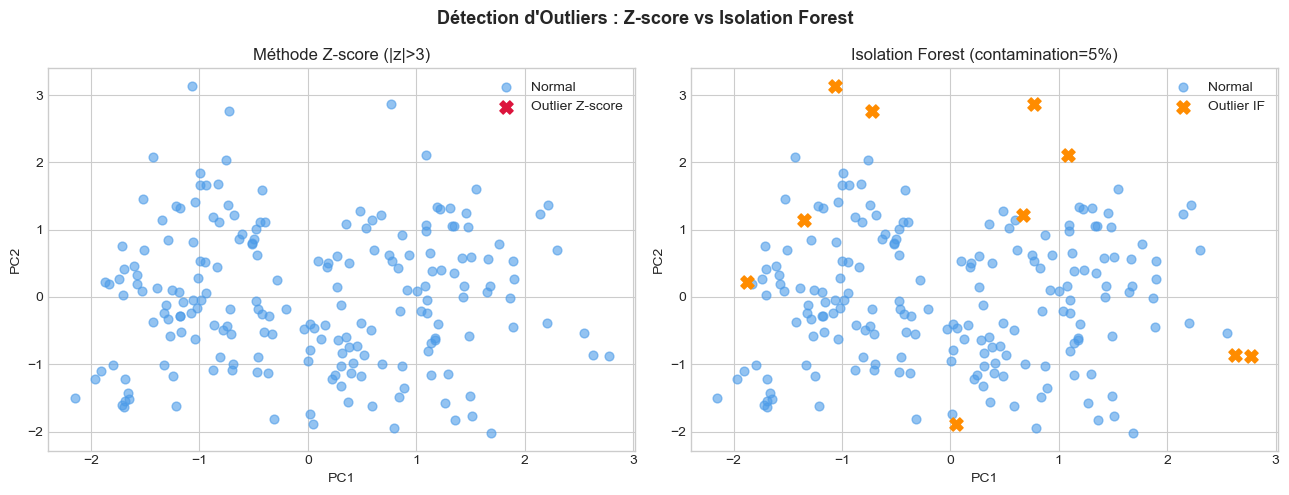

→ Isolation Forest détecte des outliers multivariés que le Z-score peut manquer.


In [11]:
# Visualisation : outliers projetés sur PCA rapide
pca_quick = PCA(n_components=2, random_state=RANDOM_STATE)
X_quick   = pca_quick.fit_transform(StandardScaler().fit_transform(df_num[features]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Détection d\'Outliers : Z-score vs Isolation Forest', fontsize=13, fontweight='bold')

# Z-score
z_mask = np.abs(zscore(df_num)).max(axis=1) > 3
axes[0].scatter(X_quick[~z_mask, 0], X_quick[~z_mask, 1],
                color='#4C9BE8', alpha=0.6, s=40, label='Normal')
axes[0].scatter(X_quick[z_mask, 0],  X_quick[z_mask, 1],
                color='crimson', s=90, marker='X', label='Outlier Z-score')
axes[0].set_title('Méthode Z-score (|z|>3)'); axes[0].legend()

# Isolation Forest
axes[1].scatter(X_quick[~outliers_iso, 0], X_quick[~outliers_iso, 1],
                color='#4C9BE8', alpha=0.6, s=40, label='Normal')
axes[1].scatter(X_quick[outliers_iso, 0],  X_quick[outliers_iso, 1],
                color='darkorange', s=90, marker='X', label='Outlier IF')
axes[1].set_title('Isolation Forest (contamination=5%)'); axes[1].legend()

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout(); plt.show()
print('→ Isolation Forest détecte des outliers multivariés que le Z-score peut manquer.')


### 2.3 Traitement des outliers (Z-score) et Standardisation

In [12]:
# Z-score : remplacement des extrêmes (|z|>3) par la médiane
z_scores = np.abs(zscore(df_num))
outlier_mask = (z_scores > 3).any(axis=1)
print(f'Outliers Z-score (|z|>3) : {outlier_mask.sum()}')
if outlier_mask.sum() > 0:
    for col in df_num.columns:
        df_num.loc[outlier_mask, col] = df_num[col].median()
    print('  → Remplacés par la médiane.')
else:
    print('  → Aucun traitement nécessaire.')

# Scalers
scaler_std = StandardScaler()
scaler_mms = MinMaxScaler()
X_std = scaler_std.fit_transform(df_num[features])
X_mms = scaler_mms.fit_transform(df_num[features])
X = X_std  # référence principale

print(f'\nShape X_std : {X_std.shape}')
print(f'Shape X_mms : {X_mms.shape}')


Outliers Z-score (|z|>3) : 0
  → Aucun traitement nécessaire.

Shape X_std : (200, 4)
Shape X_mms : (200, 4)


### 2.4 Comparaison StandardScaler vs MinMaxScaler

> **Impact sur le clustering :** On exécute K-Means avec K=5 sur les deux versions
> et on compare les métriques — cela permet de justifier le choix du scaler.


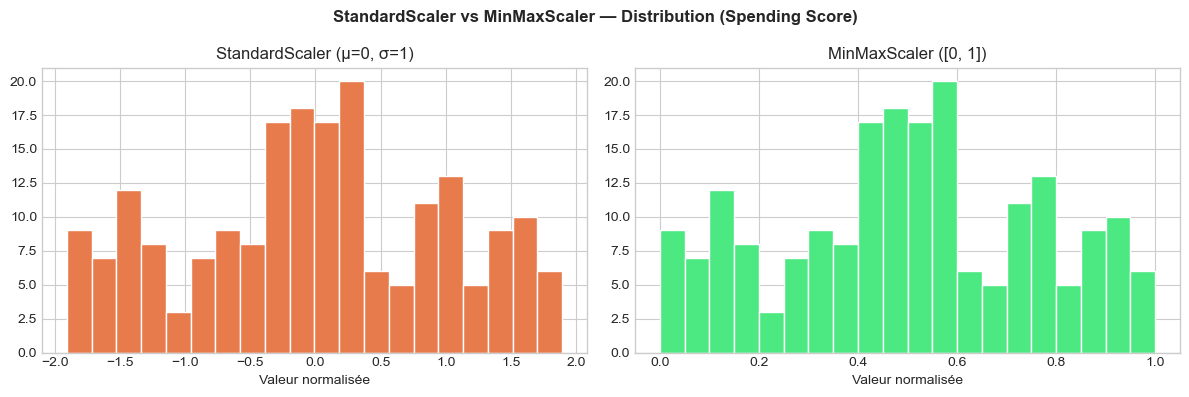

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('StandardScaler vs MinMaxScaler — Distribution (Spending Score)',
             fontsize=12, fontweight='bold')
axes[0].hist(X_std[:, 2], bins=20, color='#E87B4C', edgecolor='white')
axes[0].set_title('StandardScaler (µ=0, σ=1)'); axes[0].set_xlabel('Valeur normalisée')
axes[1].hist(X_mms[:, 2], bins=20, color='#4CE882', edgecolor='white')
axes[1].set_title('MinMaxScaler ([0, 1])'); axes[1].set_xlabel('Valeur normalisée')
plt.tight_layout(); plt.show()


In [14]:
# Impact sur K-Means : on compare les métriques obtenues avec chaque scaler
_K_COMP = 5
scaler_comparison = []
for scaler_name, X_sc in [('StandardScaler', X_std), ('MinMaxScaler', X_mms)]:
    km_sc = KMeans(n_clusters=_K_COMP, init='k-means++', n_init=20, random_state=RANDOM_STATE)
    km_sc.fit(X_sc)
    lbl = km_sc.labels_
    scaler_comparison.append({
        'Scaler': scaler_name,
        'Inertie': round(km_sc.inertia_, 2),
        'Silhouette ↑':        round(silhouette_score(X_sc, lbl), 4),
        'Davies-Bouldin ↓':    round(davies_bouldin_score(X_sc, lbl), 4),
        'Calinski-Harabasz ↑': round(calinski_harabasz_score(X_sc, lbl), 2),
    })

df_scaler_comp = pd.DataFrame(scaler_comparison)
print(f'Comparaison K-Means (K={_K_COMP}) — StandardScaler vs MinMaxScaler :\n')
print(df_scaler_comp.to_string(index=False))
print('\n→ Conclusion : StandardScaler est préféré car il gère mieux les distributions')
print('  asymétriques et est requis par DBSCAN et GMM qui utilisent les distances euclidiennes.')


Comparaison K-Means (K=5) — StandardScaler vs MinMaxScaler :

        Scaler  Inertie  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
StandardScaler   327.35        0.3144            1.1364                70.39
  MinMaxScaler    19.06        0.3709            0.9954               172.92

→ Conclusion : StandardScaler est préféré car il gère mieux les distributions
  asymétriques et est requis par DBSCAN et GMM qui utilisent les distances euclidiennes.


---
## 3. Modèles de Clustering


### 3.1 K-Means

> **Principe :** Partitionne les données en K clusters en minimisant l'inertie intra-cluster.  
> **Avantage :** Simple, rapide, interprétable.  
> **Limite :** Suppose des clusters convexes et isotropes, sensible aux initialisations.


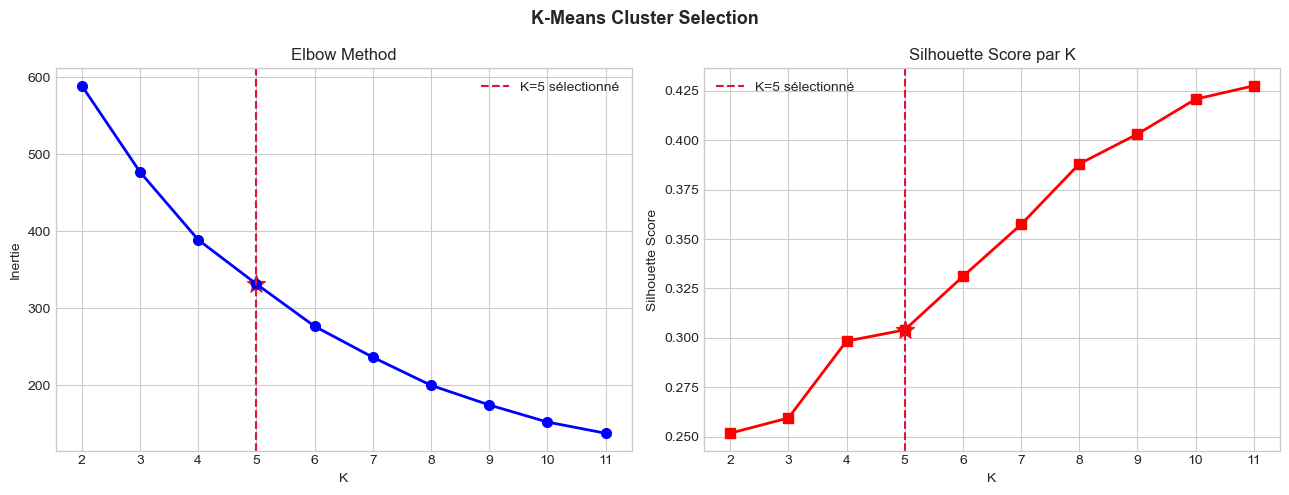

 K  Inertia  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
 2   588.80        0.2518            1.6138                71.02
 3   476.79        0.2595            1.3574                66.77
 4   388.72        0.2984            1.2807                69.13
 5   331.31        0.3041            1.1672                68.96
 6   276.41        0.3311            1.0177                73.50
 7   236.20        0.3574            0.9802                76.78
 8   199.75        0.3880            0.9445                82.42
 9   174.24        0.4031            0.8750                85.75
10   152.03        0.4208            0.8331                89.98
11   137.50        0.4275            0.8416                91.07

K retenu pour l'article : 5 (choix elbow + interprétabilité métier)


In [15]:
# K-Means : Elbow Method + Silhouette Analysis
# Important : l'article sélectionne K=5 comme compromis entre elbow + interprétabilité,
# même si la Silhouette continue d'augmenter lorsque K augmente.

K_range = range(2, 12)   # article : K ∈ [2, 11]
inertia_list = []
sil_list_km  = []
db_list_km   = []
ch_list_km   = []

for k in K_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km_temp.fit(X)
    inertia_list.append(km_temp.inertia_)
    sil_list_km.append(silhouette_score(X, km_temp.labels_))
    db_list_km.append(davies_bouldin_score(X, km_temp.labels_))
    ch_list_km.append(calinski_harabasz_score(X, km_temp.labels_))

# Valeur retenue dans l'article
SELECTED_K = 5
best_k = SELECTED_K

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means Cluster Selection', fontsize=13, fontweight='bold')

axes[0].plot(K_range, inertia_list, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(best_k, color='crimson', linestyle='--', label='K=5 sélectionné')
axes[0].scatter([best_k], [inertia_list[list(K_range).index(best_k)]], s=180, marker='*', color='crimson')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertie'); axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range)); axes[0].legend()

axes[1].plot(K_range, sil_list_km, 'rs-', linewidth=2, markersize=7)
axes[1].axvline(best_k, color='crimson', linestyle='--', label='K=5 sélectionné')
axes[1].scatter([best_k], [sil_list_km[list(K_range).index(best_k)]], s=180, marker='*', color='crimson')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score par K'); axes[1].set_xticks(list(K_range)); axes[1].legend()
plt.tight_layout(); plt.show()

# Tableau équivalent à Table 4 de l'article
km_selection_table = pd.DataFrame({
    'K': list(K_range),
    'Inertia': np.round(inertia_list, 2),
    'Silhouette ↑': np.round(sil_list_km, 4),
    'Davies-Bouldin ↓': np.round(db_list_km, 4),
    'Calinski-Harabasz ↑': np.round(ch_list_km, 2),
})
print(km_selection_table.to_string(index=False))
print(f"\nK retenu pour l'article : {best_k} (choix elbow + interprétabilité métier)")

In [16]:
# Modèle K-Means final
kmeans_model  = KMeans(n_clusters=best_k, init='k-means++', n_init=20,
                       max_iter=500, random_state=RANDOM_STATE)
kmeans_model.fit(X)
kmeans_labels = kmeans_model.labels_
print(f'Clusters : {dict(zip(*np.unique(kmeans_labels, return_counts=True)))}')


Clusters : {np.int32(0): np.int64(48), np.int32(1): np.int64(39), np.int32(2): np.int64(28), np.int32(3): np.int64(29), np.int32(4): np.int64(56)}


#### 3.1.1 Sensibilité à l'initialisation (k-means++ vs random)

> **k-means++** sélectionne les centroïdes initiaux de façon espacée → convergence plus stable.


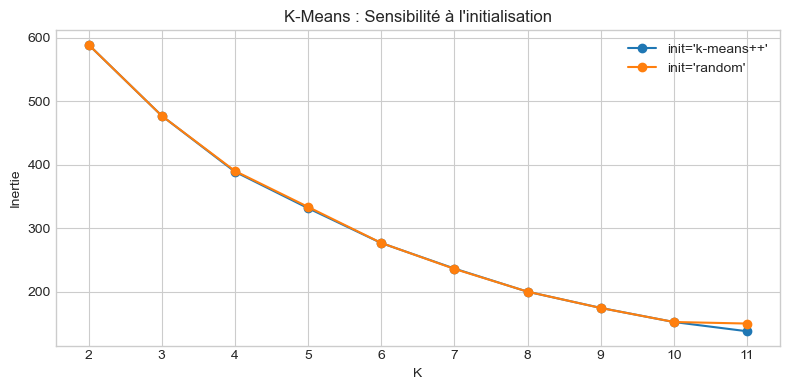

In [17]:
init_methods = ['k-means++', 'random']
fig, ax = plt.subplots(figsize=(8, 4))
for init_m in init_methods:
    ax.plot(K_range,
            [KMeans(n_clusters=k, init=init_m, n_init=10, random_state=RANDOM_STATE)
             .fit(X).inertia_ for k in K_range],
            marker='o', label=f"init='{init_m}'")
ax.set_xlabel('K'); ax.set_ylabel('Inertie')
ax.set_title("K-Means : Sensibilité à l'initialisation")
ax.legend(); ax.set_xticks(list(K_range))
plt.tight_layout(); plt.show()


#### 3.1.2 Analyse de stabilité K-Means (30 seeds)

> On exécute K-Means 30 fois avec des seeds différentes et on compare les résultats
> via l'**Adjusted Rand Index (ARI)**. Un ARI proche de 1 indique une grande stabilité.

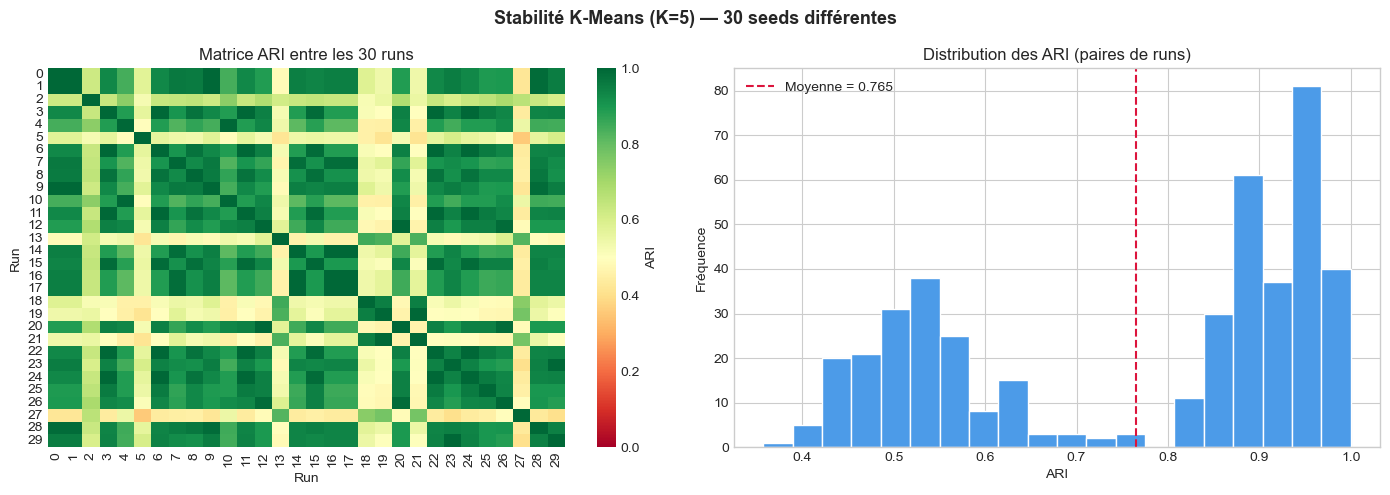

ARI moyen entre runs : 0.7651 ± 0.1998
Stabilité modérée (ARI 0.7–0.9) — les résultats peuvent varier légèrement


In [18]:
N_RUNS   = 30
all_labels_km = []

for seed in range(N_RUNS):
    km_run = KMeans(n_clusters=best_k, init='k-means++', n_init=5, random_state=seed)
    km_run.fit(X)
    all_labels_km.append(km_run.labels_)

# Matrice ARI (N_RUNS × N_RUNS)
ari_matrix = np.zeros((N_RUNS, N_RUNS))
for i in range(N_RUNS):
    for j in range(N_RUNS):
        ari_matrix[i, j] = adjusted_rand_score(all_labels_km[i], all_labels_km[j])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Stabilité K-Means (K={best_k}) — {N_RUNS} seeds différentes',
             fontsize=13, fontweight='bold')

sns.heatmap(ari_matrix, ax=axes[0], cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=range(N_RUNS), yticklabels=range(N_RUNS),
            cbar_kws={'label': 'ARI'})
axes[0].set_title(f'Matrice ARI entre les {N_RUNS} runs')
axes[0].set_xlabel('Run'); axes[0].set_ylabel('Run')

off_diag = ari_matrix[np.triu_indices(N_RUNS, k=1)]
axes[1].hist(off_diag, bins=20, color='#4C9BE8', edgecolor='white')
axes[1].axvline(off_diag.mean(), color='crimson', linestyle='--',
                label=f'Moyenne = {off_diag.mean():.3f}')
axes[1].set_xlabel('ARI'); axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des ARI (paires de runs)')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f'ARI moyen entre runs : {off_diag.mean():.4f} ± {off_diag.std():.4f}')
if off_diag.mean() > 0.9:
    print('K-Means est très stable sur ce dataset (ARI > 0.9)')
elif off_diag.mean() > 0.7:
    print('Stabilité modérée (ARI 0.7–0.9) — les résultats peuvent varier légèrement')
else:
    print("Stabilité faible — K-Means est sensible à l'initialisation")

### 3.2 DBSCAN — grille article

> **Principe :** Clustering basé sur la densité, détecte les outliers (label = -1).  
> Dans l'article, la configuration finale retenue est : **eps = 0.8**, **min_samples = 5**.

In [19]:
# Grille DBSCAN utilisée dans l'article
# eps ∈ {0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5}
# MinPts ∈ {2, 3, 5, 8}

eps_values         = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5]
min_samples_values = [2, 3, 5, 8]

dbscan_results = []
for eps in eps_values:
    for min_s in min_samples_values:
        db_temp     = DBSCAN(eps=eps, min_samples=min_s)
        labels_temp = db_temp.fit_predict(X)
        n_cl   = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = list(labels_temp).count(-1)
        valid_mask_db = labels_temp != -1
        # Article : configuration valide si >= 2 clusters et moins de 50% de bruit
        valid = (n_cl >= 2 and n_noise < 0.50 * len(labels_temp)
                 and len(np.unique(labels_temp[valid_mask_db])) >= 2)
        if valid:
            sil = silhouette_score(X[valid_mask_db], labels_temp[valid_mask_db])
        else:
            sil = np.nan
        dbscan_results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_cl, 'n_noise': n_noise,
            'pct_bruit': round(n_noise/len(labels_temp)*100, 1),
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
        })

df_dbscan_grid = pd.DataFrame(dbscan_results)
print('Grille DBSCAN (configurations valides uniquement) :')
df_dbscan_grid.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False)

Grille DBSCAN (configurations valides uniquement) :


,eps,min_samples,n_clusters,n_noise,pct_bruit,silhouette
1,0.5,3,18,49,24.5,0.4746
0,0.5,2,24,37,18.5,0.4389
11,0.7,8,5,76,38.0,0.3948
6,0.6,5,9,62,31.0,0.3407
5,0.6,3,13,26,13.0,0.3265
15,0.8,8,5,52,26.0,0.3070
4,0.6,2,18,16,8.0,0.2984
23,1.0,8,2,16,8.0,0.2946
22,1.0,5,2,13,6.5,0.2918
18,0.9,5,2,13,6.5,0.2918


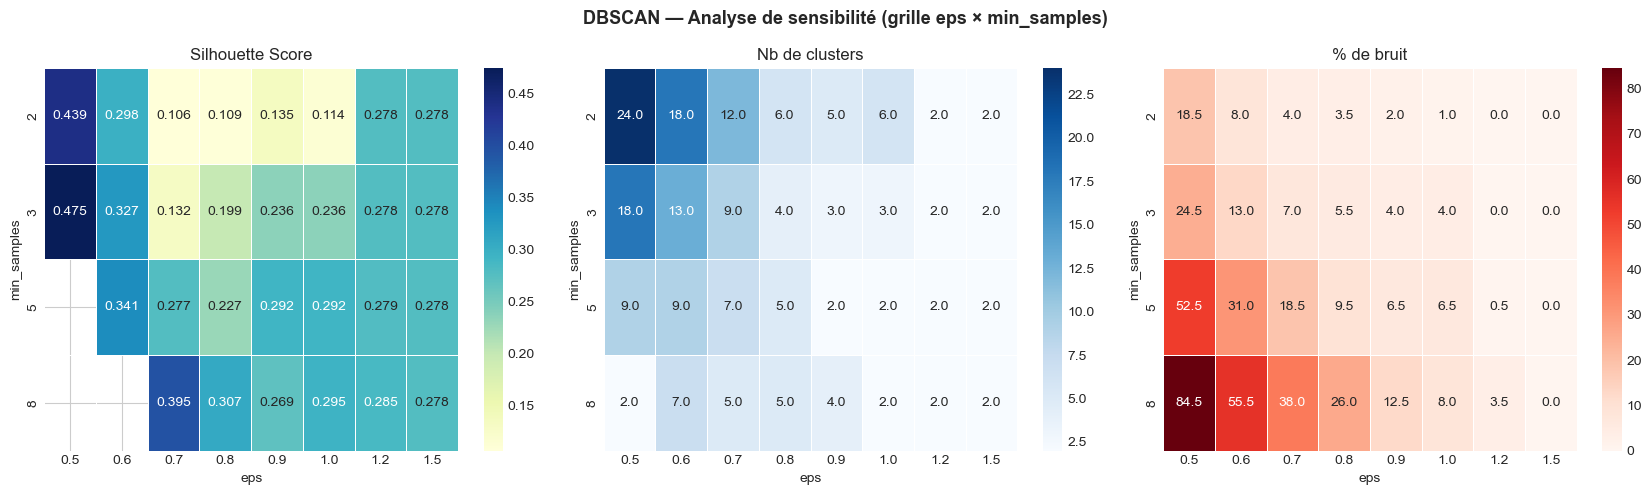

In [20]:
# Heatmap Silhouette Score
df_valid_db = df_dbscan_grid.dropna(subset=['silhouette'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('DBSCAN — Analyse de sensibilité (grille eps × min_samples)',
             fontsize=13, fontweight='bold')

for col_idx, (metric, title, cmap) in enumerate([
    ('silhouette',  'Silhouette Score', 'YlGnBu'),
    ('n_clusters',  'Nb de clusters',  'Blues'),
    ('pct_bruit',   '% de bruit',      'Reds'),
]):
    piv = df_dbscan_grid.pivot(index='min_samples', columns='eps', values=metric)
    sns.heatmap(piv, annot=True, fmt='.1f' if metric != 'silhouette' else '.3f',
                cmap=cmap, ax=axes[col_idx], linewidths=0.5)
    axes[col_idx].set_title(title)

plt.tight_layout(); plt.show()


In [21]:
# Sélection finale retenue dans l'article : compromis interprétable
# 5 clusters + proportion de bruit raisonnable.
best_eps   = 0.8
best_min_s = 5

best_row = df_dbscan_grid[(df_dbscan_grid['eps'] == best_eps) &
                          (df_dbscan_grid['min_samples'] == best_min_s)].iloc[0]

print(f"Paramètres DBSCAN retenus pour l'article : eps={best_eps}, min_samples={best_min_s}")
print(f'  Clusters = {int(best_row["n_clusters"])}  |  '
      f'Bruit = {int(best_row["n_noise"])} ({best_row["pct_bruit"]}%)  |  '
      f'Silhouette = {best_row["silhouette"]}')

Paramètres DBSCAN retenus pour l'article : eps=0.8, min_samples=5
  Clusters = 5  |  Bruit = 19 (9.5%)  |  Silhouette = 0.2273


In [22]:
# Modèle DBSCAN final avec les paramètres corrigés
dbscan_model  = DBSCAN(eps=best_eps, min_samples=best_min_s)
dbscan_labels = dbscan_model.fit_predict(X)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = list(dbscan_labels).count(-1)
print(f'Clusters détectés   : {n_clusters_db}')
print(f'Points bruit (−1)   : {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')
print(f'Distribution labels : {dict(zip(*np.unique(dbscan_labels, return_counts=True)))}')


Clusters détectés   : 5
Points bruit (−1)   : 19 (9.5%)
Distribution labels : {np.int64(-1): np.int64(19), np.int64(0): np.int64(9), np.int64(1): np.int64(94), np.int64(2): np.int64(40), np.int64(3): np.int64(26), np.int64(4): np.int64(12)}


### 3.3 Clustering Hiérarchique Agglomeratif

> **Principe :** Construit un dendrogramme par fusion itérative des clusters les plus proches.  
> **Linkage Ward :** Minimise la variance intra-cluster à chaque fusion.


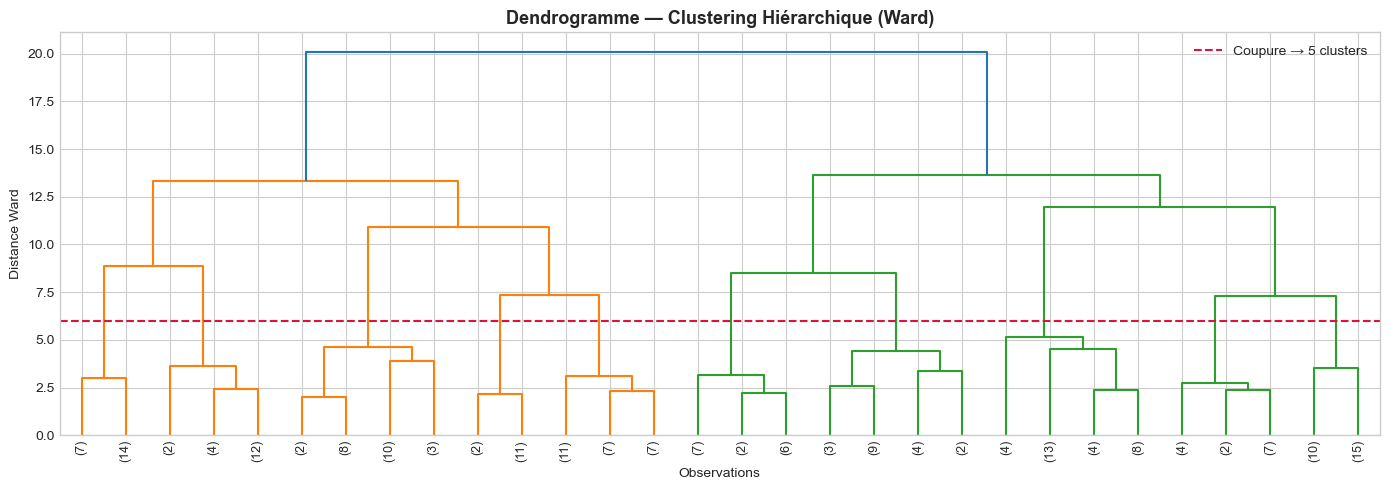

In [23]:
linkage_matrix = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9, ax=ax,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
ax.set_title('Dendrogramme — Clustering Hiérarchique (Ward)', fontsize=13, fontweight='bold')
ax.set_xlabel('Observations'); ax.set_ylabel('Distance Ward')
ax.axhline(y=6, color='crimson', linestyle='--', lw=1.5, label=f'Coupure → {best_k} clusters')
ax.legend(); plt.tight_layout(); plt.show()


In [24]:
agglo_model  = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agglo_labels = agglo_model.fit_predict(X)
print(f'Clusters : {dict(zip(*np.unique(agglo_labels, return_counts=True)))}')


Clusters : {np.int64(0): np.int64(61), np.int64(1): np.int64(39), np.int64(2): np.int64(33), np.int64(3): np.int64(38), np.int64(4): np.int64(29)}


### 3.4 Gaussian Mixture Models (GMM)

> **Principe :** Soft clustering — chaque point a une probabilité d'appartenance.  
> **BIC** (Bayesian Information Criterion) : critère de sélection du nombre de composantes.


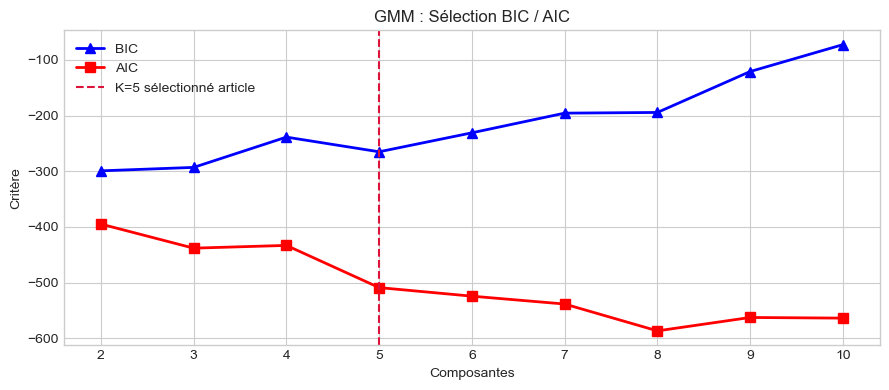

 K     BIC     AIC
 2 -299.30 -394.95
 3 -293.13 -438.25
 4 -238.69 -433.29
 5 -265.06 -509.13
 6 -230.96 -524.51
 7 -195.62 -538.65
 8 -194.38 -586.88
 9 -120.84 -562.81
10  -72.52 -563.97

K optimal selon BIC calculé : 2
K retenu pour l'article : 5 (cohérence avec K-Means K=5)


In [25]:
n_components_range = range(2, 11)
bic_scores, aic_scores = [], []
for n in n_components_range:
    gmm_t = GaussianMixture(n_components=n, covariance_type='full',
                            random_state=RANDOM_STATE, n_init=5)
    gmm_t.fit(X)
    bic_scores.append(gmm_t.bic(X)); aic_scores.append(gmm_t.aic(X))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_components_range, bic_scores, 'b^-', label='BIC', lw=2, ms=7)
ax.plot(n_components_range, aic_scores, 'rs-', label='AIC', lw=2, ms=7)
ax.axvline(5, color='crimson', linestyle='--', label='K=5 sélectionné article')
ax.set_xlabel('Composantes'); ax.set_ylabel('Critère'); ax.legend()
ax.set_title('GMM : Sélection BIC / AIC', fontsize=12); ax.set_xticks(list(n_components_range))
plt.tight_layout(); plt.show()

bic_best = list(n_components_range)[np.argmin(bic_scores)]
best_n_gmm = 5  # choix article : cohérence avec K-Means et interprétation métier

gmm_selection_table = pd.DataFrame({
    'K': list(n_components_range),
    'BIC': np.round(bic_scores, 2),
    'AIC': np.round(aic_scores, 2),
})
print(gmm_selection_table.to_string(index=False))
print(f'\nK optimal selon BIC calculé : {bic_best}')
print(f"K retenu pour l'article : {best_n_gmm} (cohérence avec K-Means K=5)")

In [26]:
gmm_model  = GaussianMixture(n_components=best_n_gmm, covariance_type='full',
                             random_state=RANDOM_STATE, n_init=10)
gmm_model.fit(X)
gmm_labels = gmm_model.predict(X)
print(f'Clusters : {dict(zip(*np.unique(gmm_labels, return_counts=True)))}')


Clusters : {np.int64(0): np.int64(21), np.int64(1): np.int64(49), np.int64(2): np.int64(59), np.int64(3): np.int64(32), np.int64(4): np.int64(39)}


### 3.5 Mean Shift

> **Principe :** Algorithme basé sur la densité — déplace itérativement chaque point
> vers la moyenne de ses voisins jusqu'à convergence.  
> **Avantage :** Pas besoin de spécifier K à l'avance.  
> **Limite :** Coûteux en calcul sur de grands datasets ; sensible au `bandwidth`.


In [27]:
# estimate_bandwidth calcule automatiquement le bandwidth optimal
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=200, random_state=RANDOM_STATE)
print(f'Bandwidth estimé : {bandwidth:.4f}')

meanshift_model  = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift_model.fit(X)
meanshift_labels = meanshift_model.labels_

n_ms = len(np.unique(meanshift_labels))
print(f'Clusters détectés : {n_ms}')
print(f'Distribution : {dict(zip(*np.unique(meanshift_labels, return_counts=True)))}')


Bandwidth estimé : 1.9700
Clusters détectés : 1
Distribution : {np.int64(0): np.int64(200)}


In [28]:
# Sensibilité au bandwidth
quantiles = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
ms_sensitivity = []
for q in quantiles:
    bw = estimate_bandwidth(X, quantile=q, n_samples=200, random_state=RANDOM_STATE)
    ms_t = MeanShift(bandwidth=bw, bin_seeding=True)
    lbl_t = ms_t.fit_predict(X)
    n_cl_t = len(np.unique(lbl_t))
    ms_sensitivity.append({'quantile': q, 'bandwidth': round(bw, 3), 'n_clusters': n_cl_t})

df_ms_sens = pd.DataFrame(ms_sensitivity)
print('Sensibilité Mean Shift au bandwidth :')
print(df_ms_sens.to_string(index=False))


Sensibilité Mean Shift au bandwidth :
 quantile  bandwidth  n_clusters
     0.10      1.460           5
     0.15      1.786           2
     0.20      1.970           1
     0.25      2.123           1
     0.30      2.256           1
     0.35      2.378           1


### 3.6 HDBSCAN (Hierarchical DBSCAN) — Bonus

> **Avantage par rapport à DBSCAN :** Gère les clusters de densité variable,
> plus robuste au choix des hyperparamètres.  
> **Hyperparamètres clés :**
> - `min_cluster_size` : taille minimale d'un cluster
> - `min_samples` : contrôle la conservativité (plus élevé = plus d'outliers)


In [29]:
# Grid Search sur les hyperparamètres HDBSCAN
min_cluster_sizes = [3, 5, 8, 10, 15]
min_samples_hdb   = [1, 3, 5]

hdb_results = []
if HDBSCAN_AVAILABLE:
    for mcs in min_cluster_sizes:
        for ms in min_samples_hdb:
            hdb_t = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms)
            lbl_t = hdb_t.fit_predict(X)
            n_cl  = len(set(lbl_t)) - (1 if -1 in lbl_t else 0)
            n_ns  = list(lbl_t).count(-1)
            valid_hdb = lbl_t != -1
            sil_h = (silhouette_score(X[valid_hdb], lbl_t[valid_hdb])
                     if n_cl >= 2 and valid_hdb.sum() > 10 else np.nan)
            hdb_results.append({
                'min_cluster_size': mcs, 'min_samples': ms,
                'n_clusters': n_cl, 'n_noise': n_ns,
                'pct_bruit': round(n_ns/len(lbl_t)*100, 1),
                'silhouette': round(sil_h, 4) if not np.isnan(sil_h) else np.nan
            })
    df_hdb_grid = pd.DataFrame(hdb_results)
    print('Grille HDBSCAN :')
    df_hdb_grid.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False)
else:

    print(' hdbscan n\'est pas disponible. La section HDBSCAN est ignorée.')

    df_hdb_grid = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'n_clusters',                                        'n_noise', 'pct_bruit', 'silhouette'])

Grille HDBSCAN :


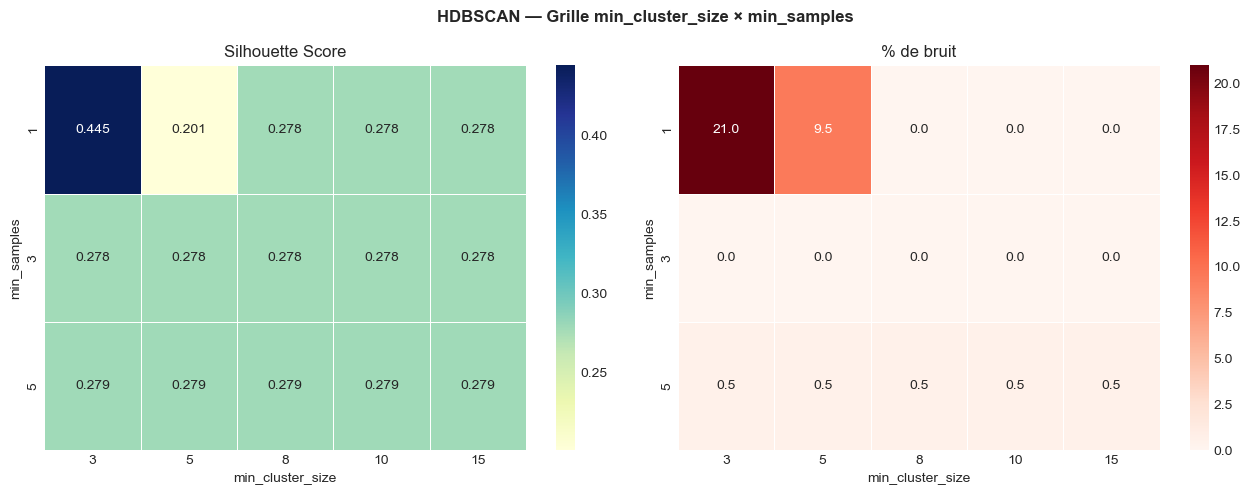

In [30]:
# Heatmap HDBSCAN
df_valid_hdb = df_hdb_grid.dropna(subset=['silhouette'])
if df_valid_hdb.empty:
    print(' Pas de résultats HDBSCAN valides pour afficher une heatmap.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('HDBSCAN — Grille min_cluster_size × min_samples', fontsize=12, fontweight='bold')

    for ax, (metric, title, cmap) in zip(axes, [
        ('silhouette', 'Silhouette Score', 'YlGnBu'),
        ('pct_bruit',  '% de bruit',      'Reds')
    ]):
        piv = df_hdb_grid.pivot(index='min_samples', columns='min_cluster_size', values=metric)
        sns.heatmap(piv, annot=True, fmt='.1f' if metric == 'pct_bruit' else '.3f',
                    cmap=cmap, ax=ax, linewidths=0.5, mask=piv.isna())
        ax.set_title(title)

    plt.tight_layout(); plt.show()


In [31]:
# Modèle HDBSCAN final — paramètres retenus dans l'article
if HDBSCAN_AVAILABLE:
    best_mcs = 5
    best_ms_hdb = 3

    hdbscan_model  = hdbscan.HDBSCAN(min_cluster_size=best_mcs, min_samples=best_ms_hdb)
    hdbscan_labels = hdbscan_model.fit_predict(X)

    n_cl_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    n_ns_hdb = list(hdbscan_labels).count(-1)
    print(f"HDBSCAN retenu pour l'article — min_cluster_size={best_mcs}, min_samples={best_ms_hdb}")
    print(f'  Clusters = {n_cl_hdb} | Bruit = {n_ns_hdb} ({n_ns_hdb/len(hdbscan_labels)*100:.1f}%)')
else:
    best_mcs = None
    best_ms_hdb = None
    hdbscan_labels = np.full(len(X), -1, dtype=int)
    print("hdbscan n'est pas disponible. HDBSCAN est ignoré et les labels sont définis comme bruit.")

HDBSCAN retenu pour l'article — min_cluster_size=5, min_samples=3
  Clusters = 2 | Bruit = 0 (0.0%)


### 3.7 Spectral Clustering — Bonus

> **Principe :** Utilise les vecteurs propres du graphe de similarité pour projeter les données
> dans un espace où les clusters sont linéairement séparables.  
> **Avantage :** Efficace pour des clusters non convexes.  
> **Limite :** Coûteux ($O(n^3)$) et nécessite de spécifier K.


In [32]:
# Sensibilité de Spectral Clustering selon K
spectral_results = []
for k in range(2, 9):
    sc_t = SpectralClustering(n_clusters=k, affinity='rbf', n_init=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
    lbl_sc = sc_t.fit_predict(X)
    sil_sc = silhouette_score(X, lbl_sc)
    spectral_results.append({'K': k, 'silhouette': round(sil_sc, 4)})

df_spectral = pd.DataFrame(spectral_results)
best_k_sc = 5  # choix article : comparaison équitable avec K-Means K=5
print(df_spectral.to_string(index=False))
print(f"\nK retenu pour Spectral Clustering dans l'article : {best_k_sc}")

 K  silhouette
 2      0.2776
 3      0.2814
 4      0.2710
 5      0.2725
 6      0.3086
 7      0.3327
 8      0.3252

K retenu pour Spectral Clustering dans l'article : 5


In [33]:
spectral_model  = SpectralClustering(n_clusters=best_k_sc, affinity='rbf',
                                     n_init=10, random_state=RANDOM_STATE, n_jobs=-1)
spectral_labels = spectral_model.fit_predict(X)
print(f'Clusters : {dict(zip(*np.unique(spectral_labels, return_counts=True)))}')


Clusters : {np.int32(0): np.int64(18), np.int32(1): np.int64(91), np.int32(2): np.int64(41), np.int32(3): np.int64(29), np.int32(4): np.int64(21)}


---
## 4. Réduction de Dimension

| Méthode | Type | Usage |
|---|---|---|
| **PCA** | Linéaire | Variance expliquée, preprocessing |
| **t-SNE** | Non linéaire | Structures locales, visualisation |
| **UMAP** | Non linéaire | Structures globales + locales, plus rapide que t-SNE |


### 4.1 PCA

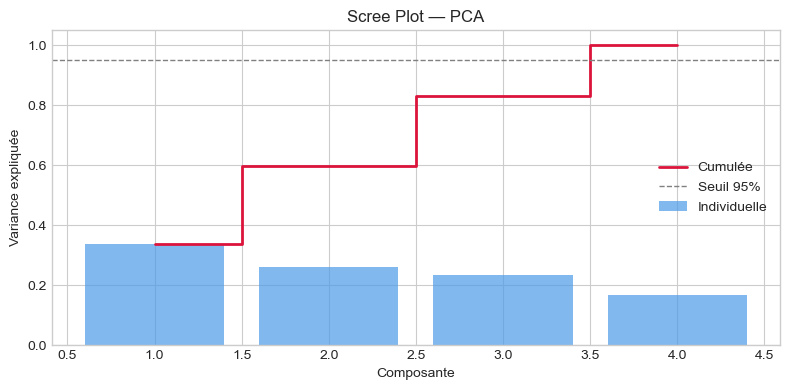

PC1=33.69%  PC2=26.23%  Total=59.92%


In [34]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
       pca_full.explained_variance_ratio_, alpha=0.7, color='#4C9BE8', label='Individuelle')
ax.step(range(1, len(cumvar)+1), cumvar, where='mid', color='crimson', lw=2, label='Cumulée')
ax.axhline(0.95, linestyle='--', color='gray', lw=1, label='Seuil 95%')
ax.set_xlabel('Composante'); ax.set_ylabel('Variance expliquée')
ax.set_title('Scree Plot — PCA', fontsize=12); ax.legend()
plt.tight_layout(); plt.show()

pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca     = pca_model.fit_transform(X)
explained_var = pca_model.explained_variance_ratio_
print(f'PC1={explained_var[0]:.2%}  PC2={explained_var[1]:.2%}  Total={sum(explained_var):.2%}')


### 4.2 t-SNE

In [35]:
tsne_model = TSNE(n_components=2, perplexity=30, max_iter=1000,
                  learning_rate='auto', init='pca', random_state=RANDOM_STATE)
X_tsne = tsne_model.fit_transform(X)
print(f't-SNE shape : {X_tsne.shape}')


t-SNE shape : (200, 2)


### 4.3 UMAP — Bonus

> **UMAP** (Uniform Manifold Approximation and Projection) préserve à la fois
> les structures locales **et** globales, tout en étant plus rapide que t-SNE.
>
> - `n_neighbors` : taille du voisinage local (comme perplexity dans t-SNE)
> - `min_dist` : distance minimale entre points dans l'espace réduit


In [36]:
if UMAP_AVAILABLE:
    umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                           random_state=RANDOM_STATE)
    X_umap = umap_model.fit_transform(X)
    print(f'UMAP shape : {X_umap.shape}')
else:
    print(' umap n\'est pas disponible. UMAP est ignoré.')
    X_umap = None


UMAP shape : (200, 2)


---
## 5. Analyses Avancées


### 5.1 ARI et NMI — Comparaison avec les labels réels (Gender)

> **ARI** (Adjusted Rand Index) et **NMI** (Normalized Mutual Information) mesurent
> la similarité entre les clusters obtenus et des labels de référence.  
> Ici, on utilise `Gender` comme pseudo-label réel pour voir si les algorithmes
> récupèrent naturellement la séparation homme/femme.


In [37]:
def ari_nmi(true_labels, pred_labels, name):
    return {
        'Modèle': name,
        'ARI':  round(adjusted_rand_score(true_labels, pred_labels), 4),
        'NMI':  round(normalized_mutual_info_score(true_labels, pred_labels), 4),
    }

ari_nmi_results = [
    ari_nmi(gender_labels, kmeans_labels,   f'K-Means (K={best_k})'),
    ari_nmi(gender_labels, dbscan_labels,   f'DBSCAN (eps={best_eps})'),
    ari_nmi(gender_labels, agglo_labels,    f'Agglomeratif (K={best_k})'),
    ari_nmi(gender_labels, gmm_labels,      f'GMM (K={best_n_gmm})'),
    ari_nmi(gender_labels, hdbscan_labels,  'HDBSCAN'),
    ari_nmi(gender_labels, spectral_labels, f'Spectral (K={best_k_sc})'),
]

df_ari_nmi = pd.DataFrame(ari_nmi_results)
print('ARI et NMI par rapport à Gender (label de référence externe) :\n')
print(df_ari_nmi.to_string(index=False))
print("\n→ Ces métriques sont utilisées uniquement comme validation externe optionnelle,")
print("  car Gender n'est pas la variable cible du clustering.")

ARI et NMI par rapport à Gender (label de référence externe) :

            Modèle    ARI    NMI
     K-Means (K=5) 0.3816 0.5317
  DBSCAN (eps=0.8) 0.5544 0.5803
Agglomeratif (K=5) 0.1124 0.2085
         GMM (K=5) 0.4292 0.6126
           HDBSCAN 1.0000 1.0000
    Spectral (K=5) 0.5636 0.6525

→ Ces métriques sont utilisées uniquement comme validation externe optionnelle,
  car Gender n'est pas la variable cible du clustering.


---
## 6. Évaluation Comparative Complète

| Métrique | Sens | Optimal |
|---|---|---|
| **Silhouette** | Cohésion + séparation | ↑ max=1 |
| **Davies-Bouldin** | Compacité inter-cluster | ↓ min=0 |
| **Calinski-Harabasz** | Ratio var. inter/intra | ↑ max=∞ |


In [38]:
def evaluate_clustering(X, labels, name, config=None):
    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    valid_mask  = labels != -1
    Xv, lv      = X[valid_mask], labels[valid_mask]
    cluster_display = f'{n_clusters} + {list(labels).count(-1)} noise' if -1 in labels else str(n_clusters)
    if n_clusters < 2 or len(np.unique(lv)) < 2:
        return {'Algorithm': name, 'Configuration': config, 'K': cluster_display,
                'Silhouette ↑': np.nan, 'Davies-Bouldin ↓': np.nan,
                'Calinski-Harabasz ↑': np.nan}
    return {
        'Algorithm': name,
        'Configuration': config,
        'K': cluster_display,
        'Silhouette ↑':        round(silhouette_score(Xv, lv), 4),
        'Davies-Bouldin ↓':    round(davies_bouldin_score(Xv, lv), 4),
        'Calinski-Harabasz ↑': round(calinski_harabasz_score(Xv, lv), 2),
    }

# Comparaison finale de l'article : 6 algorithmes uniquement
all_models = [
    (kmeans_labels,   'K-Means',       'K=5, k-means++, n_init=20'),
    (dbscan_labels,   'DBSCAN',        'eps=0.8, MinPts=5'),
    (agglo_labels,    'Agglomerative', 'Ward linkage, K=5'),
    (gmm_labels,      'GMM',           'Full covariance, K=5, n_init=10'),
    (hdbscan_labels,  'HDBSCAN',       'mcs=5, ms=3'),
    (spectral_labels, 'Spectral',      'RBF kernel, K=5, n_init=10'),
]

results = [evaluate_clustering(X, lbl, name, cfg) for lbl, name, cfg in all_models]
df_results = pd.DataFrame(results)
df_results

,Algorithm,Configuration,K,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,"K=5, k-means++, n_init=20",5,0.3144,1.1364,70.39
1,DBSCAN,"eps=0.8, MinPts=5",5 + 19 noise,0.2273,1.0817,43.08
2,Agglomerative,"Ward linkage, K=5",5,0.2870,1.2198,64.47
3,GMM,"Full covariance, K=5, n_init=10",5,0.2952,1.1759,63.98
4,HDBSCAN,"mcs=5, ms=3",2,0.2776,1.6117,66.91
5,Spectral,"RBF kernel, K=5, n_init=10",5,0.2725,1.0498,57.22


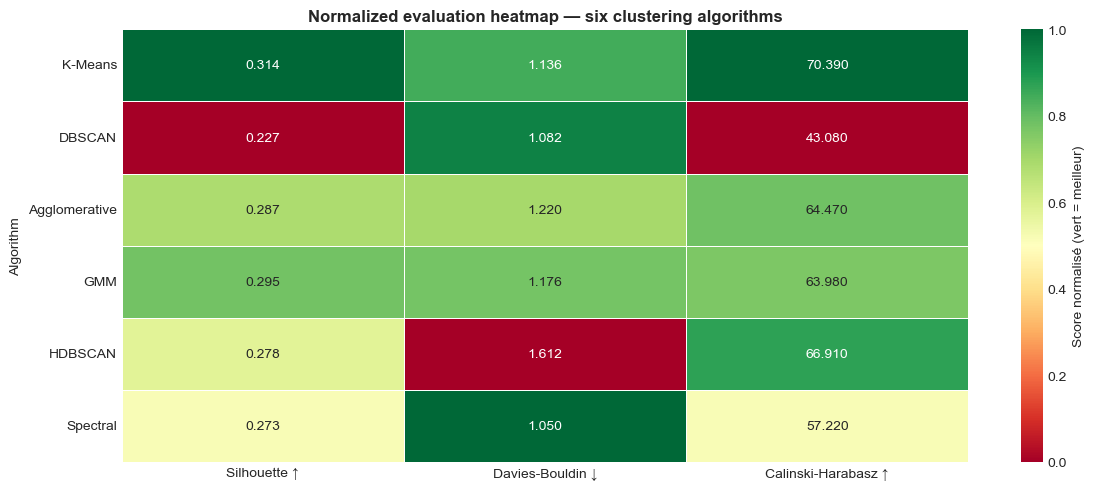


★ Meilleur modèle selon Silhouette : K-Means


In [39]:
# Heatmap normalisée (vert = meilleur dans chaque colonne)
df_numeric_eval = df_results.dropna(subset=['Silhouette ↑']).copy()
metric_cols = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑']
df_heat = df_numeric_eval.set_index('Algorithm')[metric_cols].astype(float)

df_heat_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min() + 1e-9)
df_heat_norm['Davies-Bouldin ↓'] = 1 - df_heat_norm['Davies-Bouldin ↓']

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_heat_norm, annot=df_heat.values, fmt='.3f',
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Score normalisé (vert = meilleur)'})
ax.set_title('Normalized evaluation heatmap — six clustering algorithms',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

best_model_name = df_numeric_eval.loc[df_numeric_eval['Silhouette ↑'].idxmax(), 'Algorithm']
print(f'\n★ Meilleur modèle selon Silhouette : {best_model_name}')

---
## 7. Visualisations Finales


### 7.1 Projections PCA 2D — Tous les algorithmes

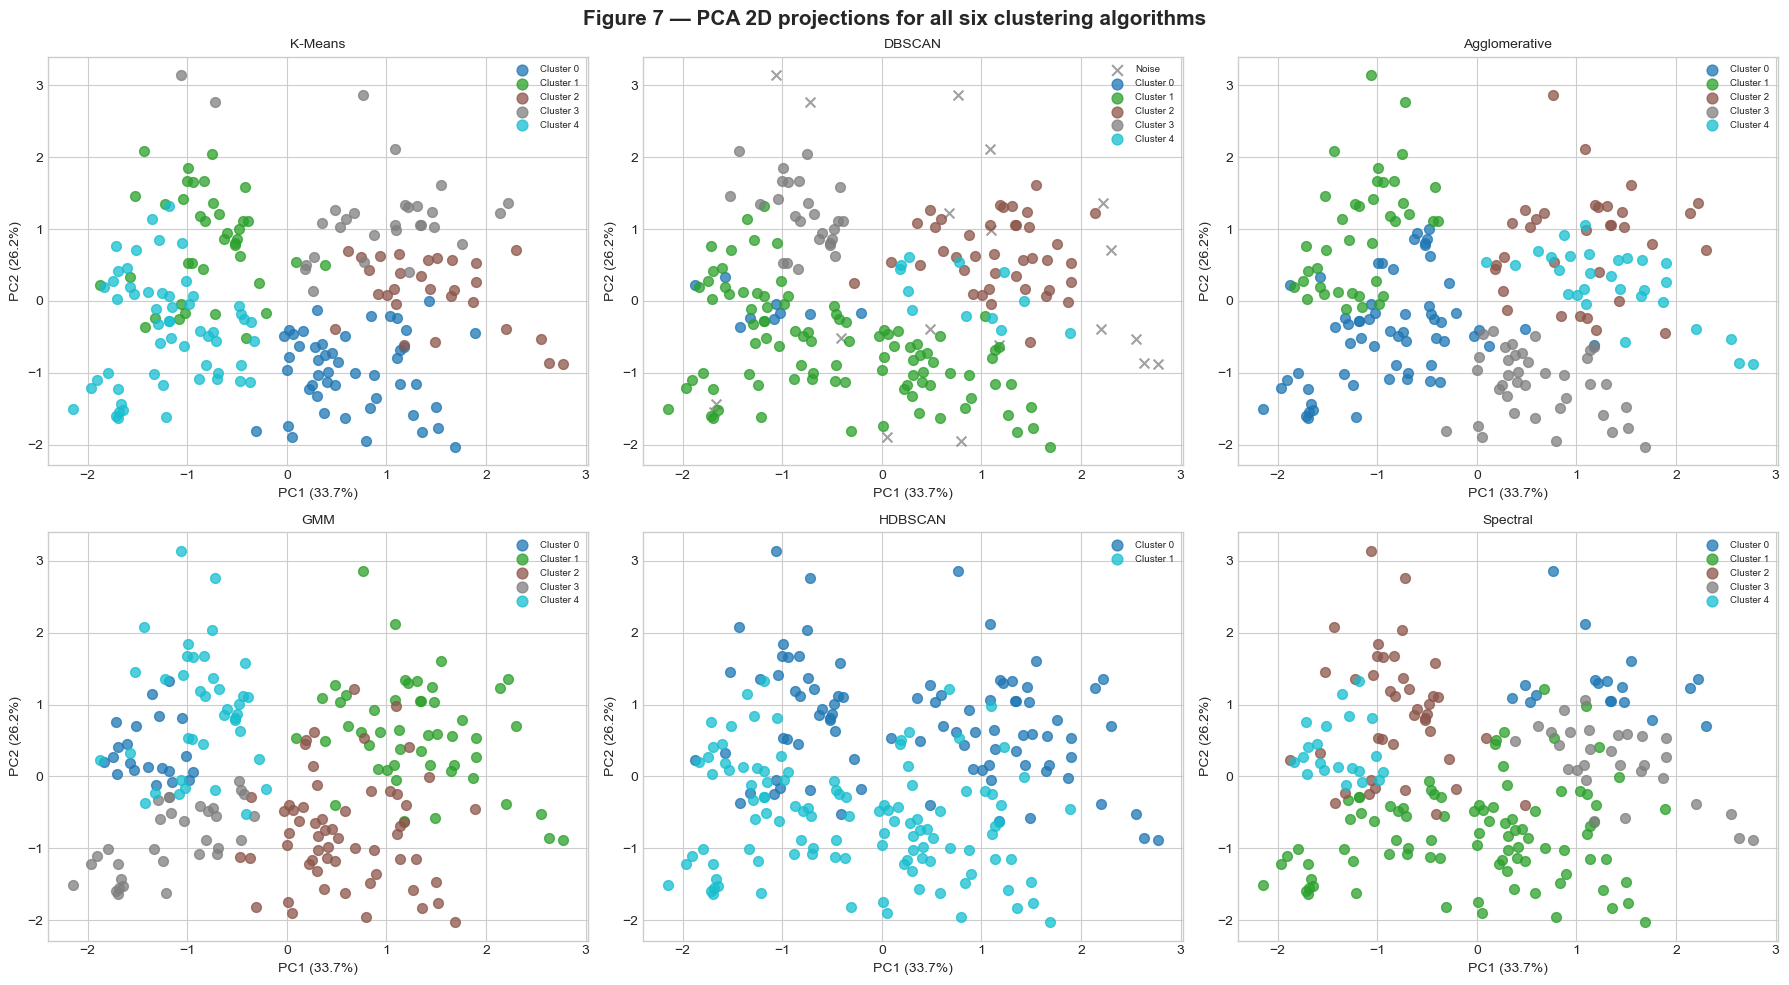

In [40]:
palette = plt.cm.tab10

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 7 — PCA 2D projections for all six clustering algorithms',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (labels, title, _) in enumerate(all_models):
    ax = axes[idx]
    unique_labels = np.unique(labels)
    max_label = max([u for u in unique_labels if u != -1], default=1)
    for lbl in unique_labels:
        mask = labels == lbl
        color     = 'gray'  if lbl == -1 else palette(lbl / max(1, max_label))
        marker    = 'x'     if lbl == -1 else 'o'
        label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], marker=marker, s=50, alpha=0.75, label=label_str)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'PC1 ({explained_var[0]:.1%})')
    ax.set_ylabel(f'PC2 ({explained_var[1]:.1%})')
    ax.legend(fontsize=7, markerscale=1.1)

plt.tight_layout(); plt.show()

### 7.2 Projections t-SNE 2D

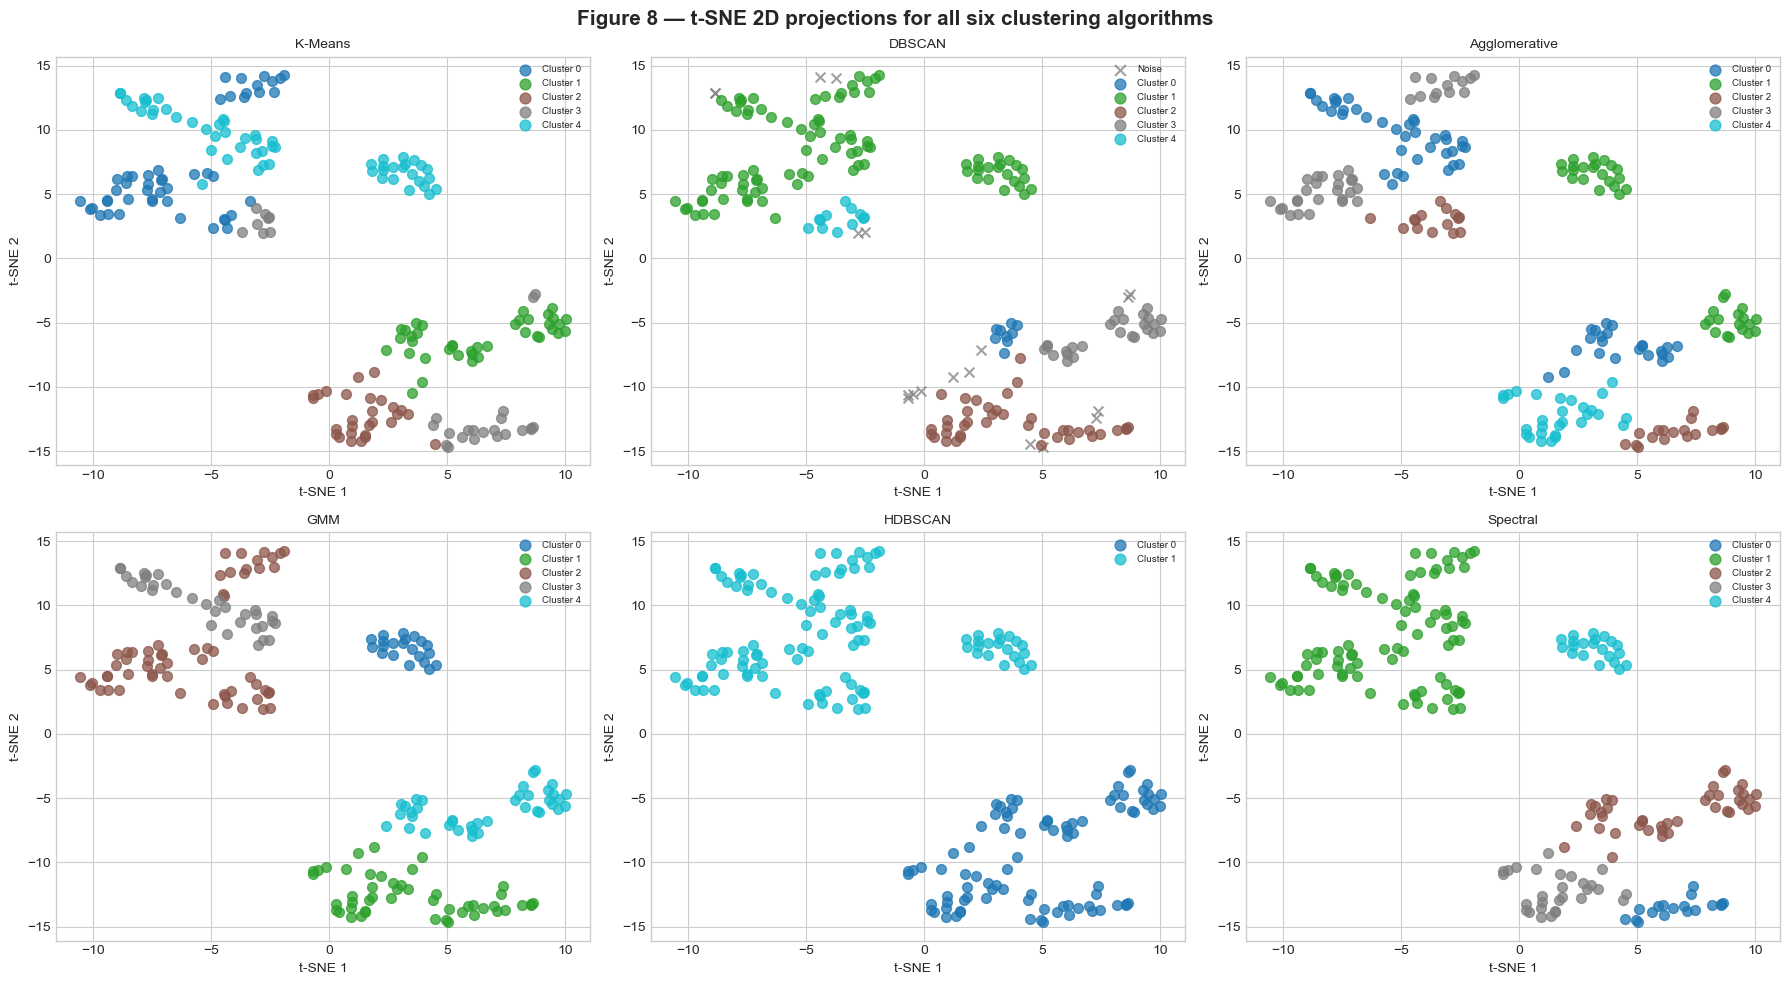

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 8 — t-SNE 2D projections for all six clustering algorithms',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (labels, title, _) in enumerate(all_models):
    ax = axes[idx]
    unique_labels = np.unique(labels)
    max_label = max([u for u in unique_labels if u != -1], default=1)
    for lbl in unique_labels:
        mask = labels == lbl
        color     = 'gray'  if lbl == -1 else palette(lbl / max(1, max_label))
        marker    = 'x'     if lbl == -1 else 'o'
        label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[color], marker=marker, s=50, alpha=0.75, label=label_str)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=7, markerscale=1.1)

plt.tight_layout(); plt.show()

### 7.3 Projections UMAP 2D

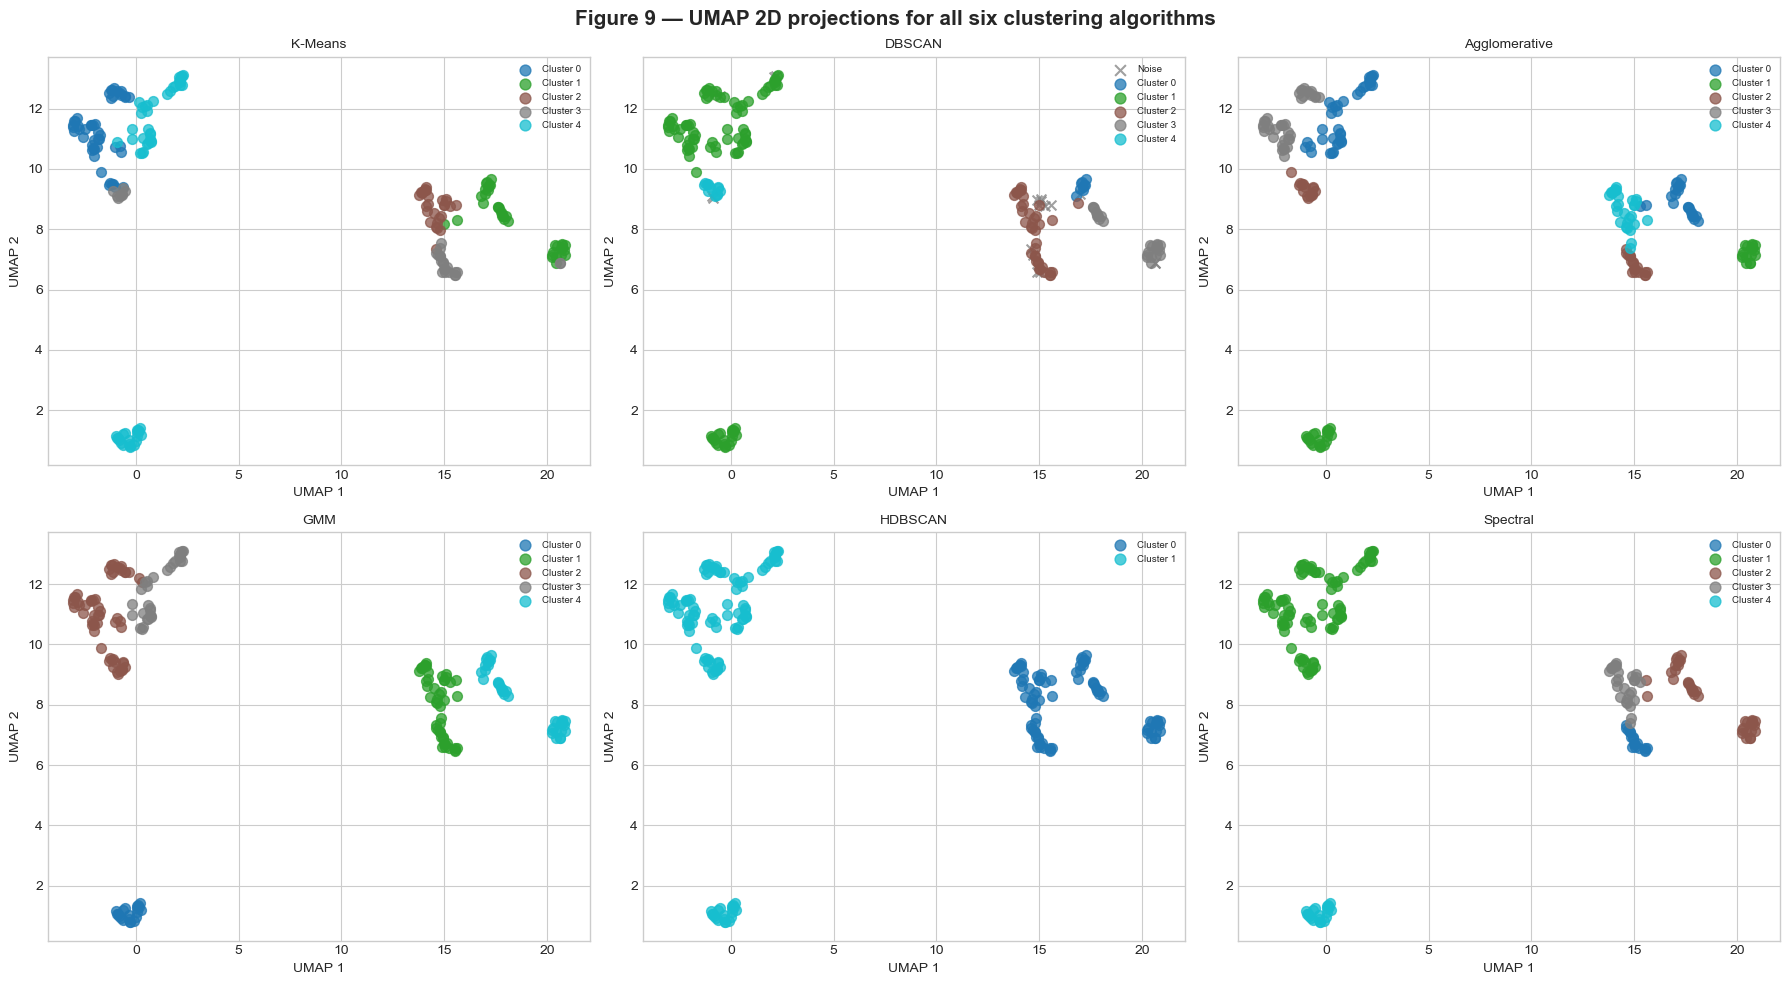

In [42]:
if UMAP_AVAILABLE and X_umap is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Figure 9 — UMAP 2D projections for all six clustering algorithms',
                 fontsize=15, fontweight='bold')
    axes = axes.flatten()

    for idx, (labels, title, _) in enumerate(all_models):
        ax = axes[idx]
        unique_labels = np.unique(labels)
        max_label = max([u for u in unique_labels if u != -1], default=1)
        for lbl in unique_labels:
            mask = labels == lbl
            color     = 'gray'  if lbl == -1 else palette(lbl / max(1, max_label))
            marker    = 'x'     if lbl == -1 else 'o'
            label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                       c=[color], marker=marker, s=50, alpha=0.75, label=label_str)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
        ax.legend(fontsize=7, markerscale=1.1)

    plt.tight_layout(); plt.show()
else:
    print('UMAP non disponible ou non calculé. La visualisation UMAP est ignorée.')

---
## 8. Interprétation Métier des Clusters (K-Means)

> On analyse le profil moyen de chaque cluster K-Means pour leur donner
> une signification concrète dans le contexte commercial du mall.


In [43]:
df_profile = df_num.copy()
df_profile['Cluster']    = kmeans_labels
df_profile['Gender_raw'] = df['Gender'].values

cluster_profile = df_profile.groupby('Cluster').agg({
    'Age':                   'mean',
    'Annual Income (k$)':    'mean',
    'Spending Score (1-100)':'mean',
    'Gender_encoded':         'mean',   # proportion de Males (=1)
    'Cluster':               'count',
}).rename(columns={'Cluster': 'Taille', 'Gender_encoded': '% Male (mean)'})
cluster_profile['% Male (mean)'] = (cluster_profile['% Male (mean)'] * 100).round(1)
cluster_profile = cluster_profile.round(2)

print('Profil moyen par cluster :\n')
print(cluster_profile)


Profil moyen par cluster :

           Age  Annual Income (k$)  Spending Score (1-100)  % Male (mean)  \
Cluster                                                                     
0        48.79               50.33                   36.40            0.0   
1        28.41               58.23                   70.72          100.0   
2        57.21               46.79                   38.71          100.0   
3        38.90               94.17                   21.83           72.4   
4        28.39               60.43                   68.18            0.0   

         Taille  
Cluster          
0            48  
1            39  
2            28  
3            29  
4            56  


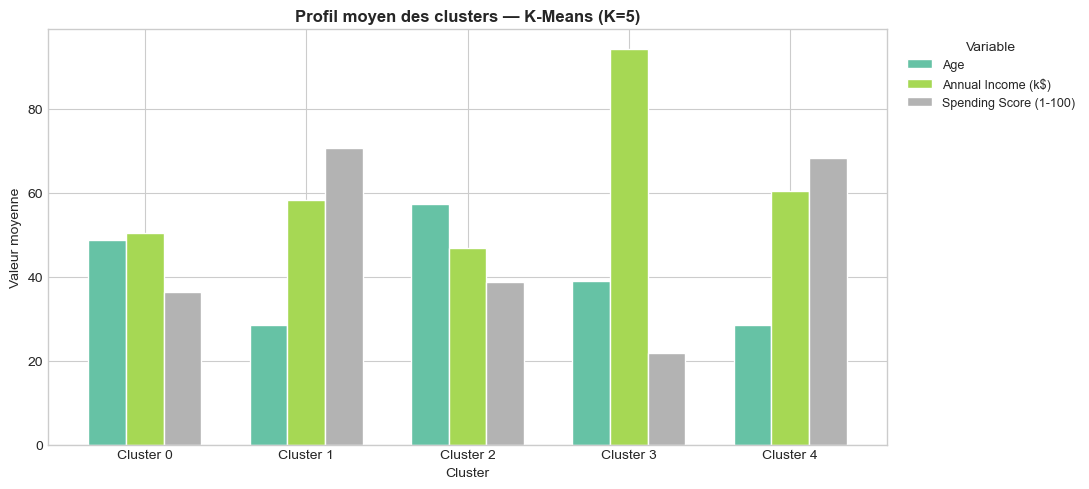

In [44]:
# Barplot groupé
num_features_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
fig, ax = plt.subplots(figsize=(11, 5))
cluster_profile[num_features_plot].plot(kind='bar', ax=ax, width=0.7,
                                         colormap='Set2', edgecolor='white')
ax.set_title(f'Profil moyen des clusters — K-Means (K={best_k})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Valeur moyenne')
ax.set_xticklabels([f'Cluster {i}' for i in cluster_profile.index], rotation=0)
ax.legend(title='Variable', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


In [45]:
# Génération automatique de l'interprétation de chaque cluster
print('=' * 65)
print('  INTERPRÉTATION MÉTIER DES CLUSTERS')
print('=' * 65)

# Seuils de catégorisation (basés sur les quartiles du dataset)
age_median    = df_num['Age'].median()
income_median = df_num['Annual Income (k$)'].median()
spend_median  = df_num['Spending Score (1-100)'].median()

for cluster_id, row in cluster_profile.iterrows():
    age_cat    = 'jeune'   if row['Age'] < age_median else 'senior'
    income_cat = 'faible'  if row['Annual Income (k$)'] < income_median * 0.8 else \
                 'élevé'   if row['Annual Income (k$)'] > income_median * 1.2 else 'moyen'
    spend_cat  = 'faibles' if row['Spending Score (1-100)'] < spend_median * 0.8 else \
                 'élevées' if row['Spending Score (1-100)'] > spend_median * 1.2 else 'modérées'
    gender_cat = 'majorité féminine' if row['% Male (mean)'] < 45 else \
                 'majorité masculine' if row['% Male (mean)'] > 55 else 'mixte'

    print(f'\nCluster {cluster_id} ({int(row["Taille"])} clients) :')
    print(f'  Âge moyen        : {row["Age"]:.1f} ans ({age_cat})')
    print(f'  Revenu moyen     : {row["Annual Income (k$)"]:.1f} k$ ({income_cat})')
    print(f'  Score dépenses   : {row["Spending Score (1-100)"]:.1f}/100 (dépenses {spend_cat})')
    print(f'  Genre            : {gender_cat} ({row["% Male (mean)"]}% hommes)')
    # Recommandation marketing automatique
    if income_cat == 'élevé' and spend_cat == 'élevées':
        rec = '→ Clients premium — Cibler avec des offres luxe et fidélisation VIP'
    elif income_cat == 'élevé' and spend_cat == 'faibles':
        rec = '→ Potentiel non exploité — Stimuler avec des promotions exclusives'
    elif income_cat == 'faible' and spend_cat == 'élevées':
        rec = '→ Clients impulsifs — Proposer des facilités de paiement'
    elif income_cat == 'faible' and spend_cat == 'faibles':
        rec = '→ Clients prudents — Mettre en avant les bonnes affaires et promos'
    else:
        rec = '→ Segment standard — Stratégie marketing équilibrée'
    print(f'  Recommandation   : {rec}')

print('\n' + '=' * 65)


  INTERPRÉTATION MÉTIER DES CLUSTERS

Cluster 0 (48 clients) :
  Âge moyen        : 48.8 ans (senior)
  Revenu moyen     : 50.3 k$ (moyen)
  Score dépenses   : 36.4/100 (dépenses faibles)
  Genre            : majorité féminine (0.0% hommes)
  Recommandation   : → Segment standard — Stratégie marketing équilibrée

Cluster 1 (39 clients) :
  Âge moyen        : 28.4 ans (jeune)
  Revenu moyen     : 58.2 k$ (moyen)
  Score dépenses   : 70.7/100 (dépenses élevées)
  Genre            : majorité masculine (100.0% hommes)
  Recommandation   : → Segment standard — Stratégie marketing équilibrée

Cluster 2 (28 clients) :
  Âge moyen        : 57.2 ans (senior)
  Revenu moyen     : 46.8 k$ (faible)
  Score dépenses   : 38.7/100 (dépenses faibles)
  Genre            : majorité masculine (100.0% hommes)
  Recommandation   : → Clients prudents — Mettre en avant les bonnes affaires et promos

Cluster 3 (29 clients) :
  Âge moyen        : 38.9 ans (senior)
  Revenu moyen     : 94.2 k$ (élevé)
  Score d

---
## 9. Résumé Final & Réponses aux Questions


### 9.1 Réponses aux questions théoriques

**Q1 : Pourquoi certains algorithmes fonctionnent-ils mieux que d'autres ?**
> K-Means et GMM supposent des clusters **convexes et isotropes**, ce qui correspond
> bien à la structure du Mall Customers dataset. DBSCAN et HDBSCAN, en revanche,
> sont conçus pour des formes arbitraires et sont plus sensibles aux paramètres.
> La performance relative dépend donc de la géométrie réelle des données.

**Q2 : Quel modèle est le plus robuste au bruit ?**
> **HDBSCAN** est le plus robuste : il identifie et isole explicitement les outliers
> sans les forcer dans un cluster. K-Means est le moins robuste car il assigne
> tous les points à un cluster, même les outliers.

**Q3 : DBSCAN détecte-t-il mieux les outliers ?**
> Oui, DBSCAN et HDBSCAN **détectent explicitement** les outliers (label = -1),
> contrairement à K-Means, GMM ou Agglomeratif qui assimilent tous les points.
> Isolation Forest est complémentaire : il détecte des outliers **multivariés**
> que DBSCAN pourrait manquer avec de mauvais paramètres.

**Q4 : Le scaling influence-t-il les résultats ?**
> **Oui, considérablement.** DBSCAN et GMM utilisent des distances euclidiennes
> et requièrent un scaling pour traiter équitablement toutes les variables.
> Sans scaling, les variables à grande échelle (revenu en k$) domineraient.
> La comparaison StandardScaler vs MinMaxScaler (section 2.4) le démontre.

**Q5 : Comment choisir le nombre optimal de clusters ?**
> - **Elbow Method** : inertie en fonction de K (K-Means)
> - **Silhouette Score** : mesure la qualité du clustering pour chaque K
> - **BIC/AIC** : critères d'information pour GMM
> - **Dendrogramme** : visualisation hiérarchique pour couper à la bonne hauteur
> - **DBSCAN/HDBSCAN** : K est déterminé automatiquement par la densité

**Q6 : Les clusters sont-ils interprétables ?**
> **Oui**, les clusters K-Means sur ce dataset correspondent à des segments
> marketing reconnaissables (clients premium, prudents, impulsifs…).
> L'analyse des profils moyens (section 8) confirme la pertinence métier.


In [46]:
# ══════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL AUTOMATIQUE — VERSION ARTICLE
# ══════════════════════════════════════════════════════════════
print('=' * 70)
print('  RÉSUMÉ FINAL — TP CLUSTERING MALL CUSTOMERS')
print('=' * 70)

print(f"""
DATASET
  • 200 clients × 5 variables  |  0 valeur manquante
  • Variables : Age, Annual Income (k$), Spending Score, Gender

PRÉTRAITEMENT
  • Suppression CustomerID (identifiant non informatif)
  • Label Encoding : Gender → 0/1
  • Outliers Z-score (|z|>3) → aucun outlier extrême détecté
  • Isolation Forest (5% contamination) → {sum(outliers_iso)} outliers détectés
  • Normalisation principale : StandardScaler

ALGORITHMES COMPARÉS DANS L'ARTICLE
  • K-Means       : K=5, k-means++, n_init=20
  • DBSCAN       : eps={best_eps}, min_samples={best_min_s}
  • Agglomerative: Ward linkage, K=5
  • GMM          : K={best_n_gmm}, covariance_type='full', n_init=10
  • HDBSCAN      : min_cluster_size={best_mcs}, min_samples={best_ms_hdb}
  • Spectral     : RBF kernel, K={best_k_sc}, n_init=10

SECTION OPTIONNELLE TP
  • Mean Shift est implémenté, mais non inclus dans la Table 7 de l'article.

RÉDUCTIONS DE DIMENSION
  PCA   : {explained_var[0]:.1%} + {explained_var[1]:.1%} = {sum(explained_var):.1%} variance expliquée en 2D
  t-SNE : Structures locales (perplexity=30)
  UMAP  : Structures locales + globales (n_neighbors=15)
""")

print('TABLEAU COMPARATIF ARTICLE — 6 ALGORITHMES')
print('-' * 70)
print(df_results.to_string(index=False))

print(f"""
ARI / NMI (vs Gender comme label de référence externe)
""")
print(df_ari_nmi.to_string(index=False))

print(f"""
★  MEILLEUR ALGORITHME (Silhouette Score) : {best_model_name}

LÉGENDE MÉTRIQUES
  Silhouette ↑        [-1, 1]  — plus élevé = clusters denses et bien séparés
  Davies-Bouldin ↓    [0, ∞)   — plus bas = clusters compacts et distincts
  Calinski-Harabasz ↑ [0, ∞)   — plus élevé = clusters bien définis
  ARI                 [-1, 1]  — accord avec les vrais labels (0 = aléatoire)
  NMI                 [0, 1]   — information mutuelle normalisée
""")
print('=' * 70)
print("Notebook corrigé pour correspondre à la méthodologie et aux choix de l'article.")
print('=' * 70)

  RÉSUMÉ FINAL — TP CLUSTERING MALL CUSTOMERS

DATASET
  • 200 clients × 5 variables  |  0 valeur manquante
  • Variables : Age, Annual Income (k$), Spending Score, Gender

PRÉTRAITEMENT
  • Suppression CustomerID (identifiant non informatif)
  • Label Encoding : Gender → 0/1
  • Outliers Z-score (|z|>3) → aucun outlier extrême détecté
  • Isolation Forest (5% contamination) → 10 outliers détectés
  • Normalisation principale : StandardScaler

ALGORITHMES COMPARÉS DANS L'ARTICLE
  • K-Means       : K=5, k-means++, n_init=20
  • DBSCAN       : eps=0.8, min_samples=5
  • Agglomerative: Ward linkage, K=5
  • GMM          : K=5, covariance_type='full', n_init=10
  • HDBSCAN      : min_cluster_size=5, min_samples=3
  • Spectral     : RBF kernel, K=5, n_init=10

SECTION OPTIONNELLE TP
  • Mean Shift est implémenté, mais non inclus dans la Table 7 de l'article.

RÉDUCTIONS DE DIMENSION
  PCA   : 33.7% + 26.2% = 59.9% variance expliquée en 2D
  t-SNE : Structures locales (perplexity=30)
  UMAP